In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df = pd.read_csv("height-weight.csv")


In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

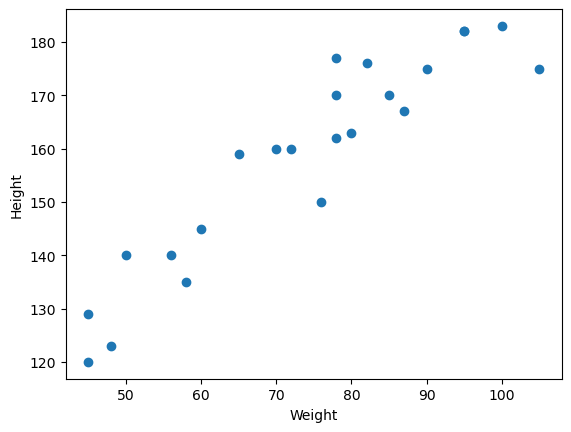

In [8]:
#Scatter plot
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

In [9]:
## Corelation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


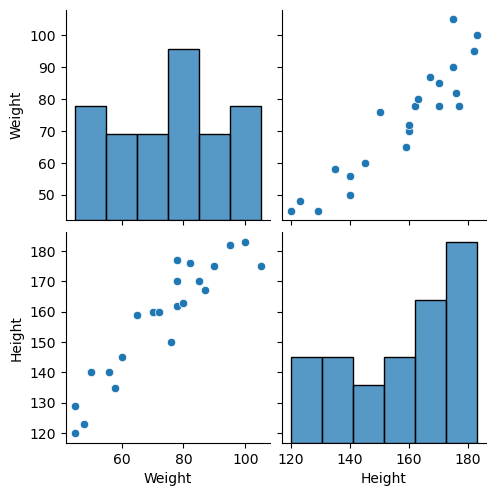

In [10]:
#Seaborn for visualization 
import seaborn as sns
sns.pairplot(df)

In [18]:
#Independent And Dependent Feature
X= df[["Weight"]]
y = df["Height"] #This variable can be in 1D array or series


In [20]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [21]:
X_train.shape

(17, 1)

In [23]:
y_train.shape

(17,)

In [24]:
#Standardization 
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [26]:
X_test = scaler.transform(X_test)

In [28]:
##Apply Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [30]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
print("Coeffiecient of Slope:",regression.coef_)
print("Intercept;",regression.intercept_)

Coeffiecient of Slope: [17.2982057]
Intercept; 156.47058823529412


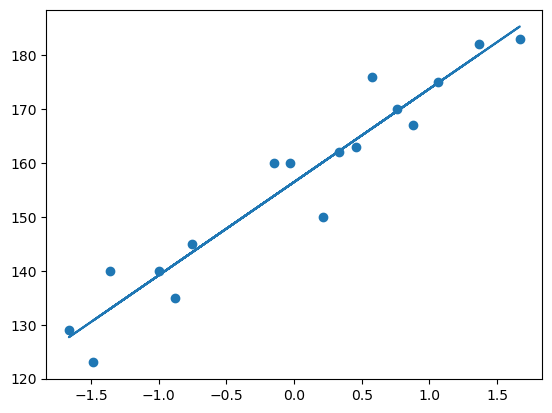

In [35]:
#Plot Training Data And best fit Line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [37]:
#Prediction for test Data
y_pred = regression.predict(X_test)


In [38]:
#Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [39]:
mse = mean_absolute_error(y_test,y_pred)
mae = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

9.665125886795005
114.84069295228699
3.10887855774313


In [40]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.7360826717981276


In [43]:
# OLS Linear Regression
import statsmodels.api as sm

In [46]:
model = sm.OLS(y_train,X_train).fit()

In [48]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [50]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 17 May 2026   Prob (F-statistic):                       0.664
Time:                        22:16:48   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [52]:
##Prediction for new data
regression.predict(scaler.transform([[72]]))

C:\Users\NIRAJ\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])